
# P166246 Data Management Final Report (WIP)
### Matrix number: P166246
### Name: Muzaffar Izamuddin bin Daud


Data source is too big and is hosted in google drive in below link
The cells in this notebook will auto download the data files from google drive if no local folder exists
https://drive.google.com/drive/folders/1aO5fiudoif1c3bJO0atcvOXCllWwncHo?usp=sharing


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muzaffarizamuddin/P166246_Data_Management_Final_Report/blob/main/historical_AQI_data_combine.ipynb)

## Load, Combine And Clean Historical AQI Data

This step combines all CSV files from the `Raw_Data_Malaysia` folder into one dataset named `historical_AQI_data.csv`.

Cleaning actions performed:
- retain only Malaysia (`MY`) records prepared in `Raw_Data_Malaysia`
- remove metadata lines and repeated headers
- keep only the required AQI columns
- standardize text values by trimming spaces
- convert date and numeric columns into suitable data types
- remove incomplete rows and duplicate records
- sort the final dataset before saving for Hive upload


In [1]:
from pathlib import Path
import pandas as pd
import gdown

raw_data_folder = Path('Raw_Data_Malaysia')
output_file = Path('Malaysia_AQI_data_combined.csv')
drive_url = "https://drive.google.com/drive/folders/13768CUaNtEXynJq8dI85Z-PwPxHpVigk"

# Fallback Logic: If local folder doesn't exist, download from Drive
if not raw_data_folder.exists():
    print(f"'{raw_data_folder}' not found locally. Downloading from Google Drive...")
    gdown.download_folder(drive_url, output=str(raw_data_folder), quiet=False)
else:
    print(f"Using local files from: {raw_data_folder}")

csv_files = sorted(raw_data_folder.glob('*.csv'))

if not csv_files:
    raise FileNotFoundError(f'No CSV files were found in {raw_data_folder}')

dataframes = []

expected_columns = ['Date', 'Country', 'City', 'Specie', 'count', 'min', 'max', 'median', 'variance']

for file in csv_files:
    df = pd.read_csv(file, comment='#', dtype=str)
    df.columns = df.columns.str.strip()
    df = df.dropna(how='all')
    df = df[expected_columns]
    dataframes.append(df)

historical_aqi_data = pd.concat(dataframes, ignore_index=True)

# Remove repeated header rows if they appear after combining files.
historical_aqi_data = historical_aqi_data[
    historical_aqi_data['Date'].astype(str).str.strip() != 'Date'
]

# Standardize text columns.
for column in ['Country', 'City', 'Specie']:
    historical_aqi_data[column] = historical_aqi_data[column].astype(str).str.strip()

# Convert columns to suitable data types.
historical_aqi_data['Date'] = pd.to_datetime(historical_aqi_data['Date'], errors='coerce')
for column in ['count', 'min', 'max', 'median', 'variance']:
    historical_aqi_data[column] = pd.to_numeric(historical_aqi_data[column], errors='coerce')

# Remove incomplete or duplicated records.
historical_aqi_data = historical_aqi_data.dropna(subset=['Date', 'Country', 'City', 'Specie'])
historical_aqi_data = historical_aqi_data.drop_duplicates()
historical_aqi_data = historical_aqi_data.sort_values(['Date', 'Country', 'City', 'Specie']).reset_index(drop=True)
historical_aqi_data['Date'] = historical_aqi_data['Date'].dt.strftime('%Y-%m-%d')

#historical_aqi_data.to_csv(output_file, index=False) #not required as we want to combine with even more data

print(f'Combined {len(csv_files)} files into {output_file.name}')
print('Files included:')
for file in csv_files:
    print(f'- {file.name}')
print(f'Total cleaned rows: {len(historical_aqi_data):,}')
historical_aqi_data.head()


Using local files from: Raw_Data_Malaysia
Combined 9 files into Malaysia_AQI_data_combined.csv
Files included:
- waqi-covid19-airqualitydata-2022Q1.csv
- waqi-covid19-airqualitydata-2022Q2.csv
- waqi-covid19-airqualitydata-2022Q3.csv
- waqi-covid19-airqualitydata-2022Q4.csv
- waqi-covid19-airqualitydata-2023Q1.csv
- waqi-covid19-airqualitydata-2023Q2.csv
- waqi-covid19-airqualitydata-2023Q3.csv
- waqi-covid19-airqualitydata-2023Q4.csv
- waqi-covid19-airqualitydata-2026.csv
Total cleaned rows: 114,218


,Date,Country,City,Specie,count,min,max,median,variance
0,2022-03-28,MY,Alor Setar,aqi,42,32.0,47.0,37.0,205.60
1,2022-03-28,MY,Alor Setar,dew,42,24.0,27.0,25.0,8.08
2,2022-03-28,MY,Alor Setar,humidity,48,66.0,100.0,88.0,1074.26
3,2022-03-28,MY,Alor Setar,pressure,48,1006.0,1012.0,1010.0,31.47
4,2022-03-28,MY,Alor Setar,temperature,48,25.0,33.0,27.0,78.87


In [2]:
historical_aqi_data.City.value_counts()

City
Malacca         9589
Kuala Lumpur    9357
Klang           9310
Alor Setar      8929
Kuantan         8746
Kota Bharu      8713
George Town     8623
Kuching         8554
Johor Bahru     8547
Seremban        8528
Taiping         8448
Ipoh            8441
Miri            8433
Name: count, dtype: int64

In [3]:
historical_aqi_data.Specie.value_counts()


Specie
humidity         17108
pressure         17108
temperature      17108
wind-speed       17108
dew              17102
aqi              15897
wind-gust         4698
pm10              1248
pm25              1248
no2               1244
so2               1244
co                1243
o3                1243
precipitation      619
Name: count, dtype: int64

In [4]:

# Need to run previous cell as data is appended onto previous data
base_data = historical_aqi_data.copy()

raw_data_folder_2 = Path('Raw_Data_Malaysia_2')
output_file = Path('Malaysia_AQI_data_combined.csv')
drive_url_2 = "https://drive.google.com/drive/folders/1obiJMmGTdbST1g0hdNzVJND9SLCBi7Fd"

# --- Fallback Clause ---
if not raw_data_folder_2.exists():
    print(f"'{raw_data_folder_2}' not found locally. Downloading from Google Drive...")
    gdown.download_folder(drive_url_2, output=str(raw_data_folder_2), quiet=False)
else:
    print(f"Using local files from: {raw_data_folder_2}")

csv_files_2 = sorted(raw_data_folder_2.glob('*.csv'))

if not csv_files_2:
    raise FileNotFoundError(f'No CSV files were found in {raw_data_folder_2}')

expected_base_columns = ['Date', 'Country', 'City', 'Specie', 'count', 'min', 'max', 'median', 'variance']
base_data.columns = base_data.columns.str.strip()
base_data = base_data[expected_base_columns].copy()

def city_from_filename(file_path: Path) -> str:
    name = file_path.stem.replace('-air-quality', '').strip()
    city = name.split(',')[0].strip(' -')
    return city.title()

extra_frames = []
for file in csv_files_2:
    df = pd.read_csv(file)
    df.columns = df.columns.str.strip().str.lower()

    if 'date' not in df.columns:
        continue

    pollutant_columns = [c for c in df.columns if c not in ['date']]
    melted = df.melt(id_vars='date', value_vars=pollutant_columns, var_name='Specie', value_name='value')

    melted['Date'] = pd.to_datetime(melted['date'], errors='coerce')
    melted['value'] = pd.to_numeric(melted['value'], errors='coerce')
    melted = melted.dropna(subset=['Date', 'value'])

    if melted.empty:
        continue

    city_name = city_from_filename(file)
    transformed = pd.DataFrame({
        'Date': melted['Date'],
        'Country': 'Malaysia',
        'City': city_name,
        'Specie': melted['Specie'].astype(str).str.strip().str.lower(),
        'count': 1,
        'min': melted['value'],
        'max': melted['value'],
        'median': melted['value'],
        'variance': 0
    })
    extra_frames.append(transformed)

if not extra_frames:
    raise ValueError('Raw_Data_Malaysia_2 files were read, but no valid rows were produced.')

extra_data = pd.concat(extra_frames, ignore_index=True)
combined_data = pd.concat([base_data, extra_data], ignore_index=True)

for column in ['Country', 'City', 'Specie']:
    combined_data[column] = combined_data[column].astype(str).str.strip()

combined_data['Date'] = pd.to_datetime(combined_data['Date'], errors='coerce')
for column in ['count', 'min', 'max', 'median', 'variance']:
    combined_data[column] = pd.to_numeric(combined_data[column], errors='coerce')

combined_data = combined_data.dropna(subset=['Date', 'Country', 'City', 'Specie'])
combined_data = combined_data.drop_duplicates()
combined_data = combined_data.sort_values(['Date', 'Country', 'City', 'Specie']).reset_index(drop=True)
combined_data['Date'] = combined_data['Date'].dt.strftime('%Y-%m-%d')

combined_data.to_csv(output_file, index=False, header=False)

print(f'Added city files: {len(csv_files_2)}')
print(f'Rows from Raw_Data_Malaysia_2: {len(extra_data):,}')
print(f'Total rows in combined file: {len(combined_data):,}')
print(f'Output: {output_file.name}')
combined_data.head()


Using local files from: Raw_Data_Malaysia_2
Added city files: 42
Rows from Raw_Data_Malaysia_2: 162,410
Total rows in combined file: 276,628
Output: Malaysia_AQI_data_combined.csv


,Date,Country,City,Specie,count,min,max,median,variance
0,2014-01-01,Malaysia,Alor-Setar,aqi,1,34.0,34.0,34.0,0.0
1,2014-01-01,Malaysia,Bakar-Arang,aqi,1,55.0,55.0,55.0,0.0
2,2014-01-01,Malaysia,Balok-Baru,aqi,1,40.0,40.0,40.0,0.0
3,2014-01-01,Malaysia,Bandaraya-Melaka,aqi,1,29.0,29.0,29.0,0.0
4,2014-01-01,Malaysia,Banting,aqi,1,41.0,41.0,41.0,0.0


In [5]:
#use pivot table to check available dates for pm25,pm10, no2 and co (major pollutants)
combined_data['Date'] = pd.to_datetime(combined_data['Date'])

date_range_pivot = combined_data.pivot_table(
    index=['City', 'Specie'], 
    values='Date', 
    aggfunc=['min', 'max']
)
date_range_pivot.columns = ['Start Date', 'End Date']
target_species = ['pm25', 'pm10', 'no2', 'co']
filtered_pivot = date_range_pivot.query("Specie in @target_species")

# ensure display does not truncate the output
pd.set_option('display.max_rows', None)

print(filtered_pivot)

                        Start Date   End Date
City             Specie                      
Alor Setar       co     2025-07-28 2025-10-31
                 no2    2025-07-28 2025-10-31
                 pm10   2025-07-28 2025-10-31
                 pm25   2025-07-28 2025-10-31
Alor-Gajah       pm10   2025-07-27 2025-10-30
                 pm25   2025-07-28 2025-10-31
Alor-Setar       no2    2025-07-27 2025-10-30
                 pm10   2025-07-27 2025-10-30
                 pm25   2025-07-28 2025-10-31
Bakar-Arang      no2    2025-07-27 2025-10-30
                 pm10   2025-07-27 2025-10-30
                 pm25   2025-07-28 2025-10-31
Balik-Pulau      no2    2025-07-27 2025-10-29
                 pm10   2025-07-27 2025-10-30
                 pm25   2025-07-28 2025-10-31
Balok-Baru       no2    2025-07-29 2025-10-30
                 pm10   2025-07-27 2025-10-30
                 pm25   2025-07-28 2025-10-31
Bandaraya-Melaka no2    2025-07-27 2025-10-30
                 pm10   2025-07-27

In [6]:
combined_data.Specie.value_counts()

Specie
aqi              163358
humidity          17108
pressure          17108
temperature       17108
wind-speed        17108
dew               17102
pm10               5280
pm25               5280
wind-gust          4698
o3                 4407
no2                4352
so2                1857
co                 1243
precipitation       619
Name: count, dtype: int64

In [8]:
combined_data.isnull().sum()

Date        0
Country     0
City        0
Specie      0
count       0
min         0
max         0
median      0
variance    0
dtype: int64

In [9]:
#this cell is a helper function to show images from github
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

def show_github_img(repo_path):
    """Fetches and displays an image directly from your GitHub repo."""
    base_url = "https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/"
    full_url = base_url + repo_path
    
    try:
        response = requests.get(full_url)
        img = Image.open(BytesIO(response.content))
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error loading image from {full_url}: {e}")

Next I used Ambari hive view to upload table and explore the data before going further

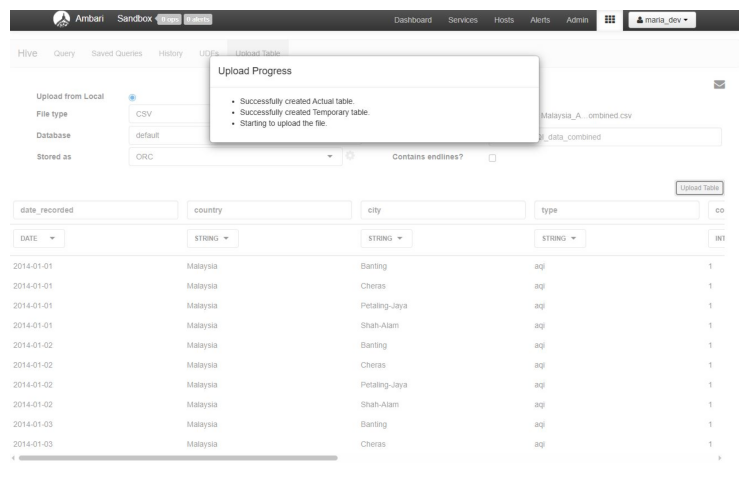

In [10]:
show_github_img("images/upload_table.JPG")

Example Hive data filtering as below image

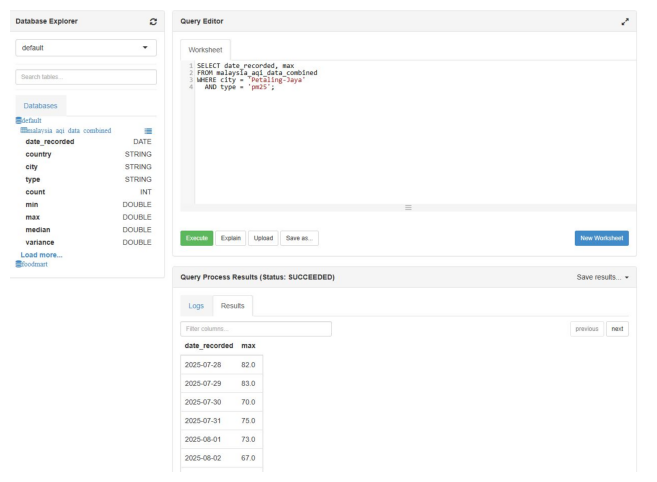

In [53]:
show_github_img("images/pm25_petaling_jaya.JPG")

I then upload combine_data into ambari using File view then use Pig to filter down to specific pollutant (PM2.5 only)

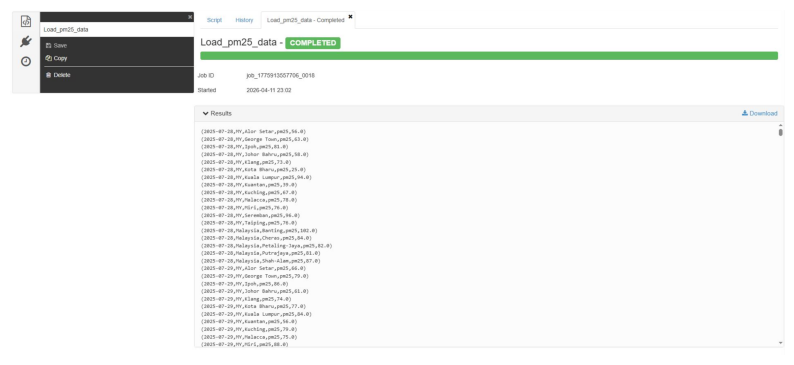

In [54]:

show_github_img("images/pig_success.JPG")

The data is then saved into github for further visualization

In [11]:
import pandas as pd
import os

# Define file info
file_name = 'pm25_only_pigoutput.csv'
column_names = ['date_recorded', 'country', 'city', 'type', 'median']
github_raw_url = f'https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/{file_name}'

# Fallback Logic: Check if file exists locally, otherwise pull from GitHub
if os.path.exists(file_name):
    print(f"--- Loading {file_name} from local directory ---")
    df_pm25 = pd.read_csv(file_name, names=column_names)
else:
    print(f"--- Local file not found. Pulling {file_name} from GitHub (Colab Mode) ---")
    df_pm25 = pd.read_csv(github_raw_url, names=column_names)

# Ensure date is in datetime format for your plots
df_pm25['date_recorded'] = pd.to_datetime(df_pm25['date_recorded'])

df_pm25.head()

--- Loading pm25_only_pigoutput.csv from local directory ---


,date_recorded,country,city,type,median
0,2025-07-28,MY,Alor Setar,pm25,56.0
1,2025-07-28,MY,George Town,pm25,63.0
2,2025-07-28,MY,Ipoh,pm25,81.0
3,2025-07-28,MY,Johor Bahru,pm25,58.0
4,2025-07-28,MY,Klang,pm25,73.0


In [12]:
#use plotly for interactive plot since many data is plotted at once
import plotly.express as px

fig = px.line(df_pm25, 
              x="date_recorded", 
              y="median", 
              color="city",
              title="PM2.5 Levels by City: July - Oct 2025",
              labels={"median": "PM2.5 Concentration", "date_recorded": "Date"})

fig.update_layout(hovermode="x unified") # Shows all values for a date when hovering
fig.show()

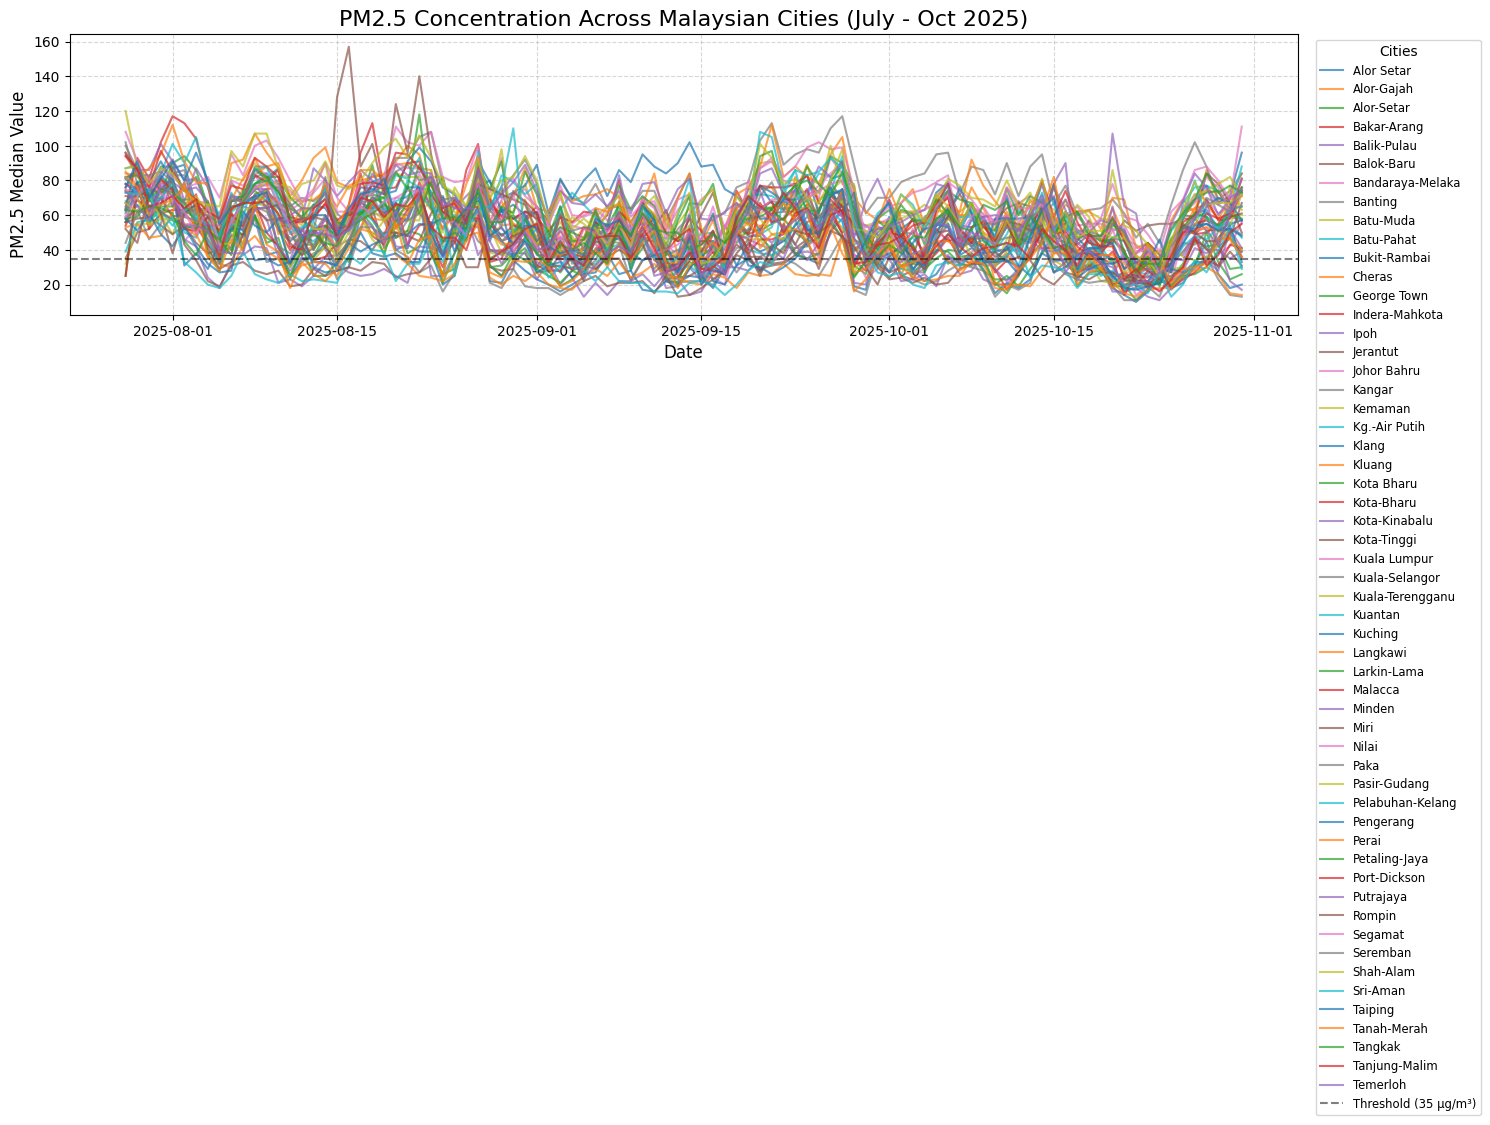

In [13]:
#matplotlib version plotting with addition of WHO threshold
# 1. Prepare data
df_pm25['date_recorded'] = pd.to_datetime(df_pm25['date_recorded'])
df_pm25 = df_pm25.sort_values(['city', 'date_recorded'])

# 2. Setup the plot
plt.figure(figsize=(15, 8))

# 3. Plot each city
for city in df_pm25['city'].unique():
    city_data = df_pm25[df_pm25['city'] == city]
    plt.plot(city_data['date_recorded'], 
             city_data['median'], 
             label=city, 
             linewidth=1.5, 
             alpha=0.7)

# 4. Add a horizontal line for the WHO / Malaysian API 'Unhealthy' threshold 
# PM2.5 threshold for 'Unhealthy' is often cited around 35-55 µg/m³ depending on the standard
plt.axhline(y=35, color='black', linestyle='--', alpha=0.5, label='Threshold (35 µg/m³)')

# 5. Labels and Styling
plt.title('PM2.5 Concentration Across Malaysian Cities (July - Oct 2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('PM2.5 Median Value', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move legend outside the plot
plt.legend(title="Cities", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=1)
plt.tight_layout()
plt.show()

From the plot, there was several findings:
1) It was found that there is a peak in high PM2.5 reading in September 15 2025 - October 1 2025 through out the 18 cities. It is suspected that this is the haze season where higher air quality readings are observed
2) Almost all areas are above the recommended safe air quality level of 35ugm3. Malaysia actually does not have a very good air quality level and can be improved
3) Peak of PM2.5 is observed on september 27

In [14]:
# Define file info
file_name = 'pm10_only_pigoutput.csv'
column_names = ['date_recorded', 'country', 'city', 'type', 'median']
github_raw_url = f'https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/{file_name}'

# Fallback Logic: Check if file exists locally, otherwise pull from GitHub
if os.path.exists(file_name):
    print(f"--- Loading {file_name} from local directory ---")
    df_pm10 = pd.read_csv(file_name, names=column_names)
else:
    print(f"--- Local file not found. Pulling {file_name} from GitHub ---")
    df_pm10 = pd.read_csv(github_raw_url, names=column_names)

# Ensure date is in datetime format for your plots
df_pm10['date_recorded'] = pd.to_datetime(df_pm10['date_recorded'])

df_pm10.head()

--- Loading pm10_only_pigoutput.csv from local directory ---


,date_recorded,country,city,type,median
0,2025-07-27,Malaysia,Alor-Gajah,pm10,34.0
1,2025-07-27,Malaysia,Alor-Setar,pm10,23.0
2,2025-07-27,Malaysia,Bakar-Arang,pm10,27.0
3,2025-07-27,Malaysia,Balik-Pulau,pm10,25.0
4,2025-07-27,Malaysia,Balok-Baru,pm10,16.0


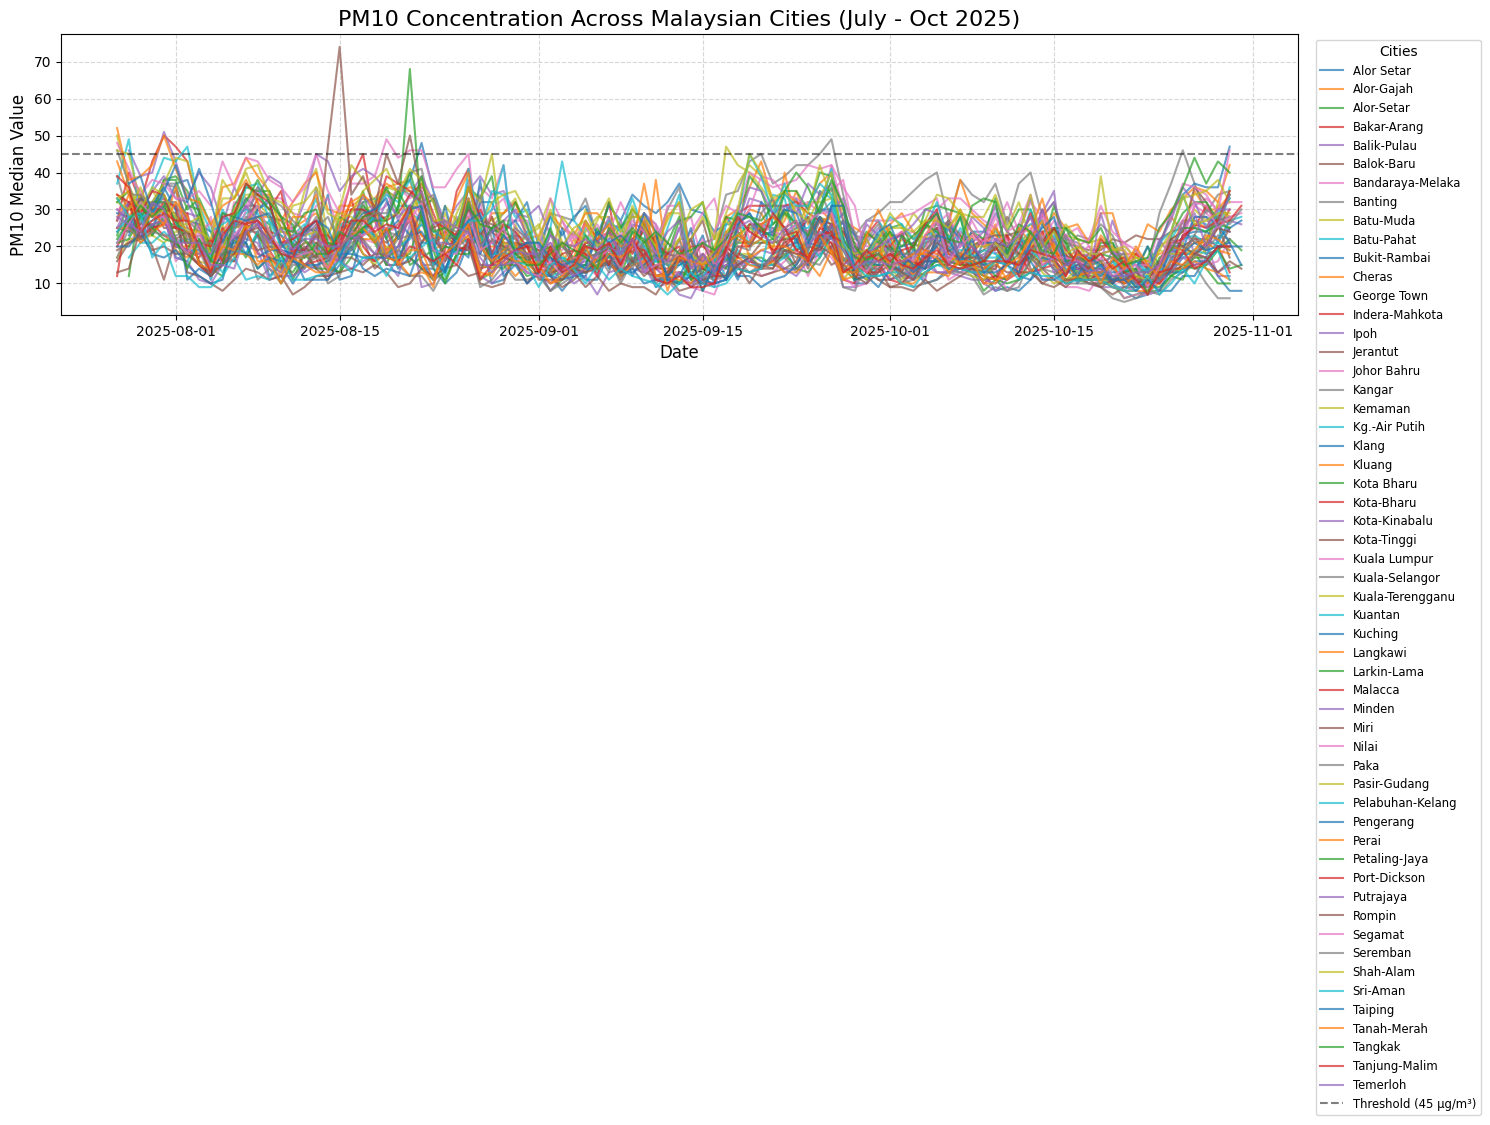

In [15]:
#plot pm10 data
# 1. Prepare data
df_pm10['date_recorded'] = pd.to_datetime(df_pm10['date_recorded'])
df_pm10 = df_pm10.sort_values(['city', 'date_recorded'])

# 2. Setup the plot
plt.figure(figsize=(15, 8))

# 3. Plot each city
for city in df_pm10['city'].unique():
    city_data = df_pm10[df_pm10['city'] == city]
    plt.plot(city_data['date_recorded'], 
             city_data['median'], 
             label=city, 
             linewidth=1.5, 
             alpha=0.7)

# 4. Add a horizontal line for the WHO / Malaysian API 'Unhealthy' threshold 
# PM2.5 threshold for 'Unhealthy' is often cited around 35-55 µg/m³ depending on the standard
plt.axhline(y=45, color='black', linestyle='--', alpha=0.5, label='Threshold (45 µg/m³)')

# 5. Labels and Styling
plt.title('PM10 Concentration Across Malaysian Cities (July - Oct 2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('PM10 Median Value', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move legend outside the plot
plt.legend(title="Cities", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=1)
plt.tight_layout()
plt.show()

Next we add data for co and no2 - these are two more pollutant that is popular when analyzing air quality
Load_co_data.pig and Load_no2_data.pig is run in VM / Ambari
then output is saved as co_only_pigoutput and no2_only_pigoutput

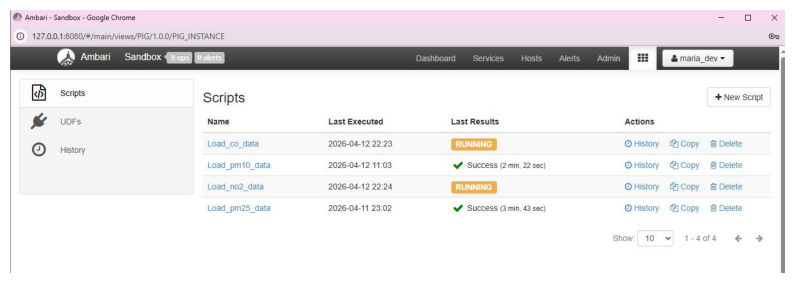

In [60]:
show_github_img("images/co_no2_pigrunning.JPG")

In [17]:
# Define file info
file_name = 'no2_only_pigoutput.csv'
column_names = ['date_recorded', 'country', 'city', 'type', 'median']
github_raw_url = f'https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/{file_name}'

# Fallback Logic: Check if file exists locally, otherwise pull from GitHub
if os.path.exists(file_name):
    print(f"--- Loading {file_name} from local directory ---")
    df_no2 = pd.read_csv(file_name, names=column_names)
else:
    print(f"--- Local file not found. Pulling {file_name} from GitHub ---")
    df_no2 = pd.read_csv(github_raw_url, names=column_names)

# Ensure date is in datetime format for your plots
df_no2['date_recorded'] = pd.to_datetime(df_no2['date_recorded'])

df_no2.head()

--- Loading no2_only_pigoutput.csv from local directory ---


,date_recorded,country,city,type,median
0,2025-07-27,Malaysia,Alor-Setar,no2,4.0
1,2025-07-27,Malaysia,Bakar-Arang,no2,3.0
2,2025-07-27,Malaysia,Balik-Pulau,no2,3.0
3,2025-07-27,Malaysia,Bandaraya-Melaka,no2,3.0
4,2025-07-27,Malaysia,Banting,no2,8.0


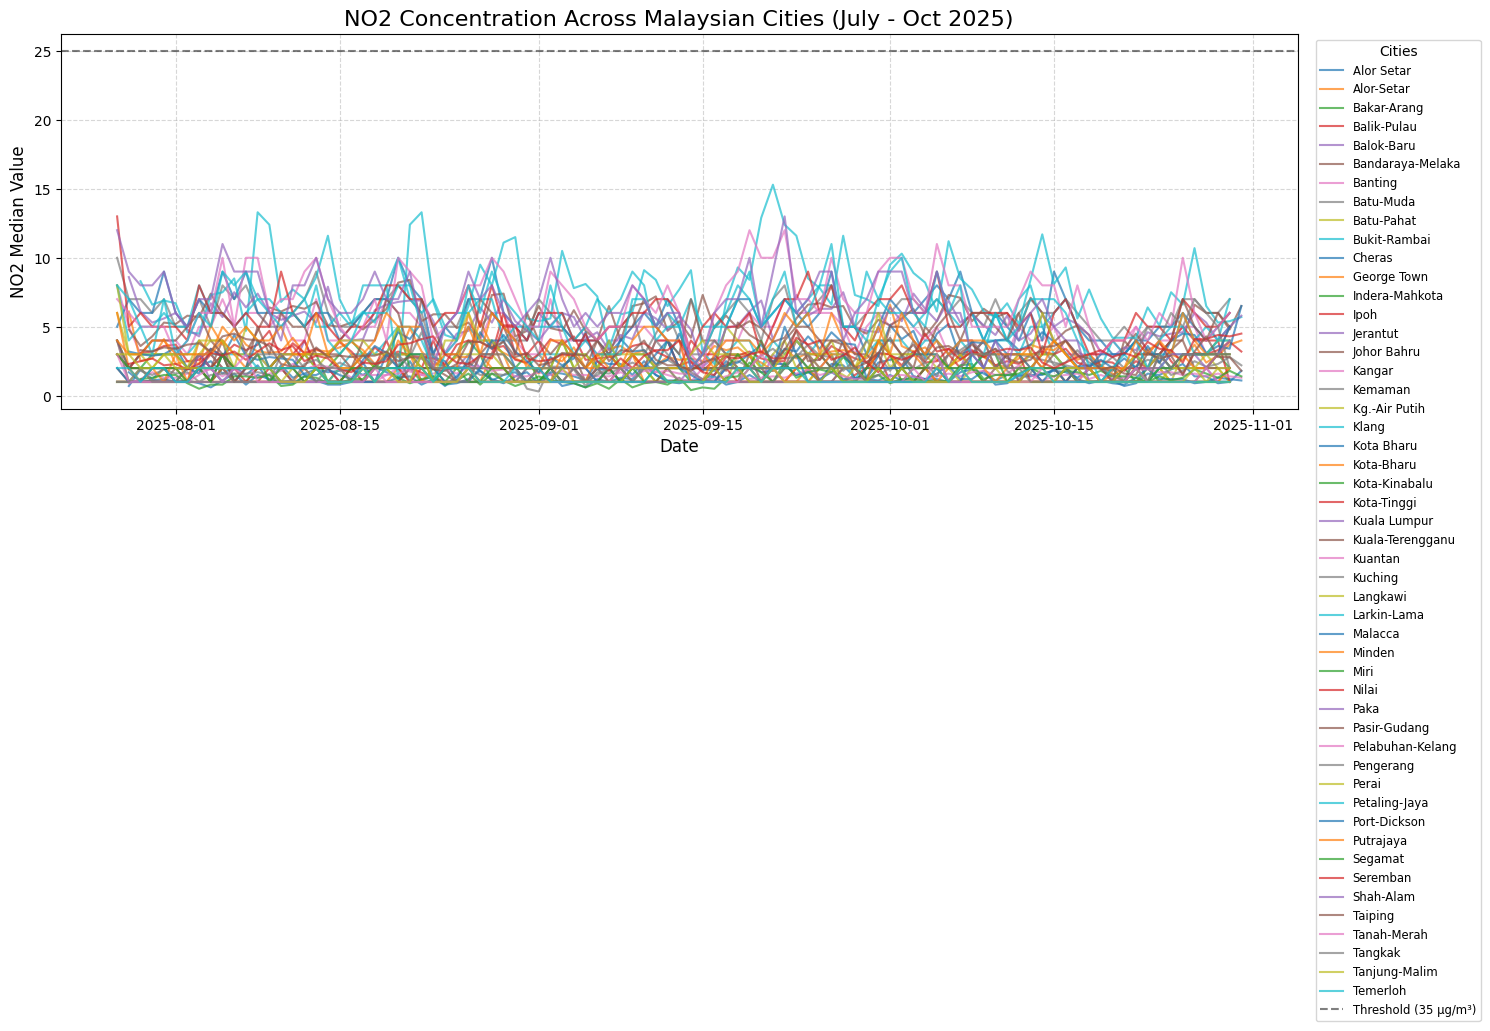

In [19]:
#plot no2 data
df_no2['date_recorded'] = pd.to_datetime(df_no2['date_recorded'])
df_no2 = df_no2.sort_values(['city', 'date_recorded'])

# 2. Setup the plot
plt.figure(figsize=(15, 8))
# 3. Plot each city
for city in df_no2['city'].unique():
    city_data = df_no2[df_no2['city'] == city]
    plt.plot(city_data['date_recorded'], 
             city_data['median'], 
             label=city, 
             linewidth=1.5, 
             alpha=0.7)

# 4. Add a horizontal line for the WHO / Malaysian API 'Unhealthy' threshold 
# PM10 threshold for 'Unhealthy' is often cited around 35-55 µg/m³ depending on the standard
plt.axhline(y=25, color='black', linestyle='--', alpha=0.5, label='Threshold (35 µg/m³)')

# 5. Labels and Styling
plt.title('NO2 Concentration Across Malaysian Cities (July - Oct 2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('NO2 Median Value', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move legend outside the plot
plt.legend(title="Cities", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=1)
plt.tight_layout()
plt.show()

In [20]:
# Define file info
file_name = 'co_only_pigoutput.csv'
column_names = ['date_recorded', 'country', 'city', 'type', 'median']
github_raw_url = f'https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/{file_name}'

# Fallback Logic: Check if file exists locally, otherwise pull from GitHub
if os.path.exists(file_name):
    print(f"--- Loading {file_name} from local directory ---")
    df_co = pd.read_csv(file_name, names=column_names)
else:
    print(f"--- Local file not found. Pulling {file_name} from GitHub ---")
    df_co = pd.read_csv(github_raw_url, names=column_names)

# Ensure date is in datetime format for your plots
df_co['date_recorded'] = pd.to_datetime(df_co['date_recorded'])

df_co.head()

--- Loading co_only_pigoutput.csv from local directory ---


,date_recorded,country,city,type,median
0,2025-07-28,MY,Alor Setar,co,0.1
1,2025-07-28,MY,George Town,co,0.1
2,2025-07-28,MY,Ipoh,co,0.1
3,2025-07-28,MY,Johor Bahru,co,0.1
4,2025-07-28,MY,Kota Bharu,co,0.1


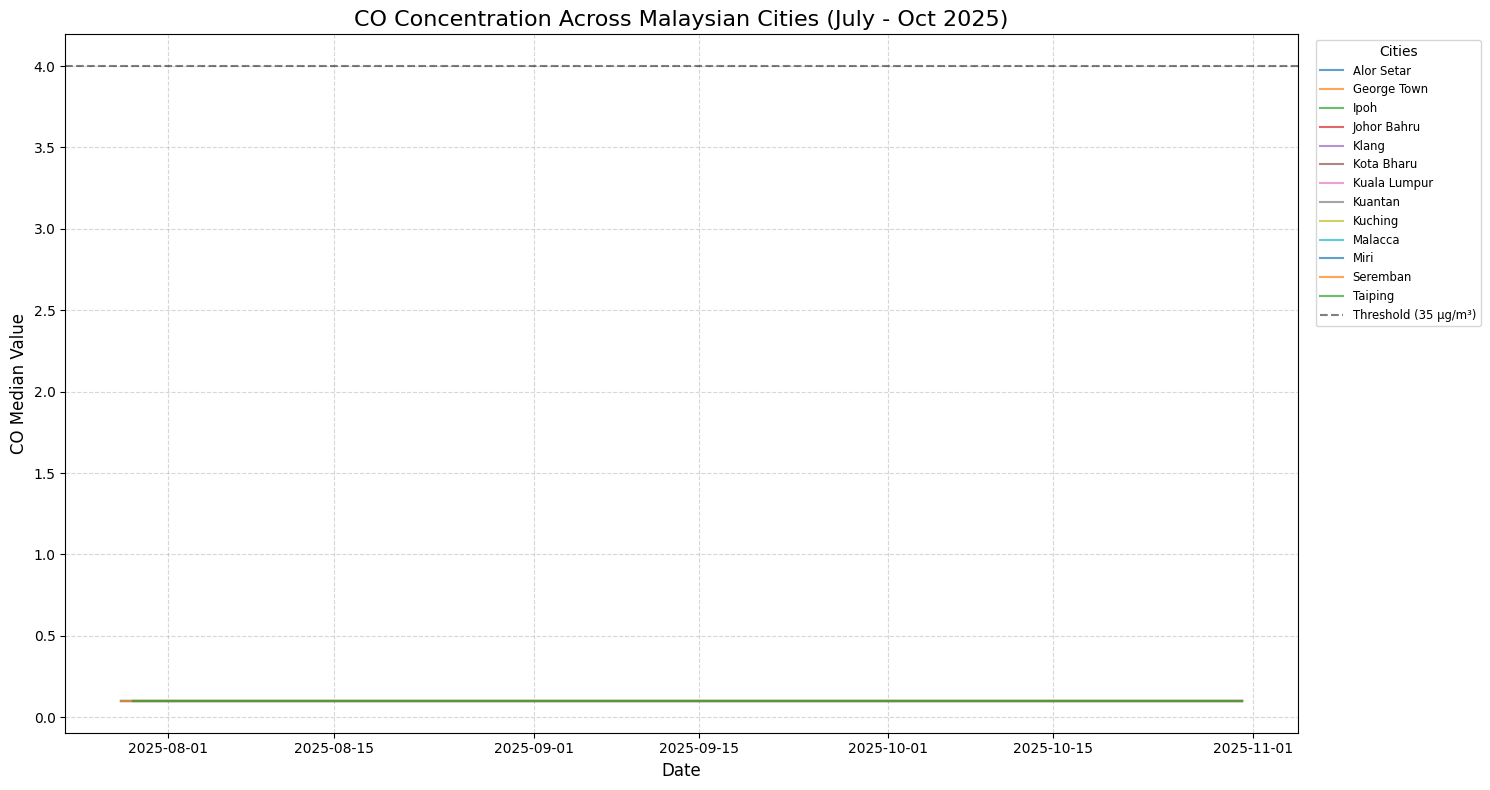

In [21]:
#plot co data
df_co['date_recorded'] = pd.to_datetime(df_co['date_recorded'])
df_co = df_co.sort_values(['city', 'date_recorded'])

# 2. Setup the plot
plt.figure(figsize=(15, 8))
# 3. Plot each city
for city in df_co['city'].unique():
    city_data = df_co[df_co['city'] == city]
    plt.plot(city_data['date_recorded'], 
             city_data['median'], 
             label=city, 
             linewidth=1.5, 
             alpha=0.7)

# 4. Add a horizontal line for the WHO / Malaysian API 'Unhealthy' threshold 
# PM10 threshold for 'Unhealthy' is often cited around 35-55 µg/m³ depending on the standard
plt.axhline(y=4, color='black', linestyle='--', alpha=0.5, label='Threshold (35 µg/m³)')

# 5. Labels and Styling
plt.title('CO Concentration Across Malaysian Cities (July - Oct 2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('CO Median Value', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move legend outside the plot
plt.legend(title="Cities", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=1)
plt.tight_layout()
plt.show()

What we see from the four plots:
1. Only PM2.5 concentration levels is above the recommended healthy limit stipulated by WHO at 35u g/m^3
2. CO is very low, almost non existant
3. NO2 is alse quite low. Readings range between 0-15u g/m^3 and is within safe limits
4. PM10 only has 1 spike above the recommended limit

Next, we will focus our analysis on PM2.5 as this is shown to be the main pollutant that has consistently exceeded the safe limits
We want to plot the pm2.5 readings on a map to see which areas are highly polluted.

In [22]:
df_pm25.head()

,date_recorded,country,city,type,median
0,2025-07-28,MY,Alor Setar,pm25,56.0
55,2025-07-29,MY,Alor Setar,pm25,66.0
110,2025-07-30,MY,Alor Setar,pm25,58.0
165,2025-07-31,MY,Alor Setar,pm25,66.0
220,2025-08-01,MY,Alor Setar,pm25,87.0


In [23]:
import pandas as pd
from geopy.geocoders import ArcGIS
from geopy.extra.rate_limiter import RateLimiter

# Check if df_final already exists and has the required columns
if 'df_final' in locals() and 'latitude' in df_final.columns and 'longitude' in df_final.columns:
    print("Coordinates already exist in df_final. Skipping geocoding to save time.")
else:
    # 1. Initialize ArcGIS
    geolocator = ArcGIS(timeout=10)
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=0.2)

    # 2. Get the unique cities
    unique_cities = df_pm25[['city', 'country']].drop_duplicates().copy()
    unique_cities['address'] = unique_cities['city'] + ', ' + unique_cities['country']

    # 3. Geocode only the unique names
    print(f"Geocoding {len(unique_cities)} unique cities...")
    unique_cities['location'] = unique_cities['address'].apply(geocode)
    unique_cities['latitude'] = unique_cities['location'].apply(lambda loc: loc.latitude if loc else None)
    unique_cities['longitude'] = unique_cities['location'].apply(lambda loc: loc.longitude if loc else None)

    # --- THE FIX ---
    # Drop latitude/longitude from df_pm25 if they already exist to avoid _x and _y suffixes
    cols_to_drop = [c for c in ['latitude', 'longitude', 'address', 'location'] if c in df_pm25.columns]
    df_pm25_clean = df_pm25.drop(columns=cols_to_drop)

    # 4. Merge back to get clean 'latitude' and 'longitude' columns
    df_final = df_pm25_clean.merge(
        unique_cities[['city', 'country', 'latitude', 'longitude']], 
        on=['city', 'country'], 
        how='left'
    )
    print("Done! Geocoding complete and coordinates assigned to df_final.")

print(df_final.head())

Geocoding 55 unique cities...
Done! Geocoding complete and coordinates assigned to df_final.
  date_recorded country        city  type  median  latitude  longitude
0    2025-07-28      MY  Alor Setar  pm25    56.0  6.121073   100.3698
1    2025-07-29      MY  Alor Setar  pm25    66.0  6.121073   100.3698
2    2025-07-30      MY  Alor Setar  pm25    58.0  6.121073   100.3698
3    2025-07-31      MY  Alor Setar  pm25    66.0  6.121073   100.3698
4    2025-08-01      MY  Alor Setar  pm25    87.0  6.121073   100.3698


Loading shapefile from local directory.


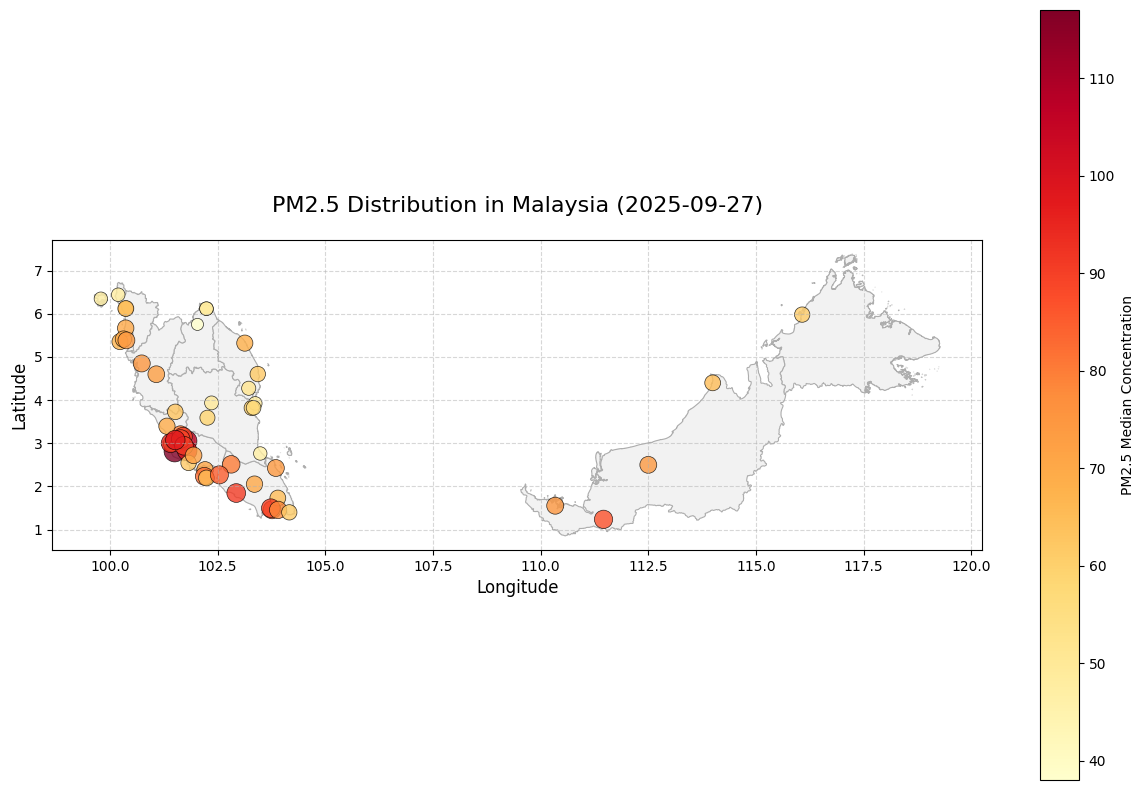

In [25]:
import os
import requests
import geopandas as gpd

def load_malaysia_map():
    local_file = 'mys_admin1.shp'
    
    extensions = ['.shp', '.shx', '.dbf', '.prj', '.cpg']
    base_url = "https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/mys_admin1"

    # Check if the main .shp file exists locally
    if not os.path.exists(local_file):
        print("Shapefile not found locally. Downloading from GitHub...")
        for ext in extensions:
            target_url = base_url + ext
            response = requests.get(target_url)
            
            if response.status_code == 200:
                with open(f'mys_admin1{ext}', 'wb') as f:
                    f.write(response.content)
                print(f"Successfully downloaded: mys_admin1{ext}")
            else:
                print(f"Failed to download {ext}. Status code: {response.status_code}")
    else:
        print("Loading shapefile from local directory.")

    return gpd.read_file(local_file)

#save malaysia map shapefile locally
malaysia_map = load_malaysia_map()

# 2. Filter for your specific date
target_date = '2025-09-27'
df_sept27 = df_final[df_final['date_recorded'] == target_date].copy()

# 3. Create GeoDataFrame
gdf_pm25 = gpd.GeoDataFrame(
    df_sept27, 
    geometry=gpd.points_from_xy(df_sept27.longitude, df_sept27.latitude),
    crs="EPSG:4326"
)

# 4. Plotting
fig, ax = plt.subplots(figsize=(15, 10))
malaysia_map.plot(ax=ax, color='#f2f2f2', edgecolor='#adadad', linewidth=0.8)

# Plot the PM2.5 points
scatter = gdf_pm25.plot(
    ax=ax, 
    column='median', 
    cmap='YlOrRd', 
    markersize=df_sept27['median'] * 2, 
    legend=True, 
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': "PM2.5 Median Concentration"}
)

# --- AXIS & LABELS ---
ax.set_axis_on() # Ensure the axes are visible
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5) # Add a grid for easier coordinate reading

plt.title(f"PM2.5 Distribution in Malaysia ({target_date})", fontsize=16, pad=20)

plt.show()

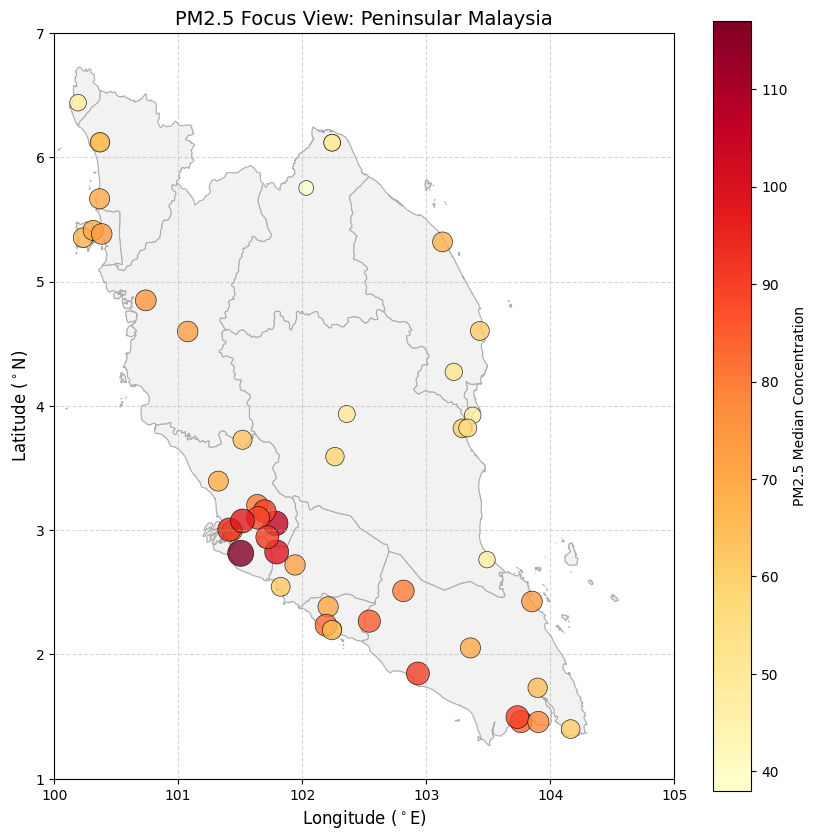

In [26]:
# This cell assumes 'malaysia_map' and 'gdf_pm25' were defined in the previous cell
fig, ax = plt.subplots(figsize=(10, 10))

malaysia_map.plot(ax=ax, color='#f2f2f2', edgecolor='#adadad', linewidth=0.8)

gdf_pm25.plot(
    ax=ax, 
    column='median', 
    cmap='YlOrRd', 
    markersize=gdf_pm25['median'] * 3, # Dot size scales with values
    legend=True, 
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': "PM2.5 Median Concentration"}
)

# 3. Focus/Crop the view
ax.set_xlim([100, 105])
ax.set_ylim([1, 7])

# 4. Axes and labels (using raw strings 'r' to avoid SyntaxWarnings)
ax.set_axis_on()
ax.set_xlabel(r"Longitude ($^\circ$E)", fontsize=12)
ax.set_ylabel(r"Latitude ($^\circ$N)", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.title("PM2.5 Focus View: Peninsular Malaysia", fontsize=14)
plt.show()